Approximate Dynamic Programming Example
Rewards Matrix:
[[ 5 10]
 [ 2  3]
 [ 8  1]]

Transition Matrix:
[[[0.7 0.2 0.1]
  [0.1 0.6 0.3]]

 [[0.3 0.4 0.3]
  [0.5 0.3 0.2]]

 [[0.4 0.4 0.2]
  [0.2 0.5 0.3]]]
Value Function after Value Iteration:
[68.06812368 62.62261531 67.13251955]
Hooke-Jeeves Method Example
Optimized parameters: [0. 0.]
Policy evaluation: -32.934051678737205
Monte Carlo Policy Search Example
Policy Search for Portfolio Management
Optimized weights: [0.49351191 0.11787144 0.02298937 0.36562728]


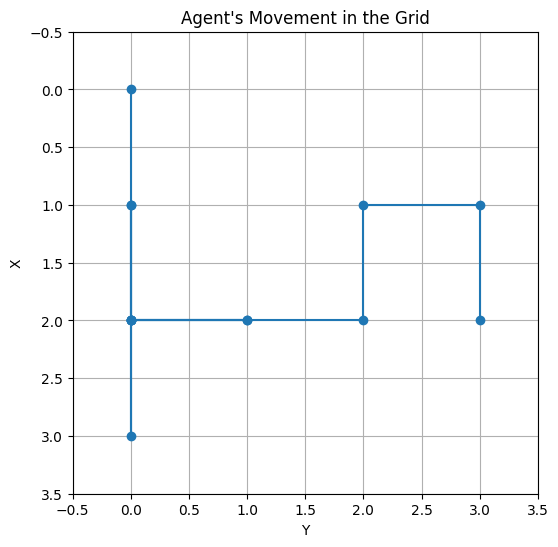

In [1]:

import numpy as np # Import the numpy library and alias it as np
# Define states
states = ['s1', 's2', 's3']

# Define actions
actions = ['a1', 'a2']

# Define rewards
rewards = {
    's1': {'a1': 5, 'a2': 10},
    's2': {'a1': 2, 'a2': 3},
    's3': {'a1': 8, 'a2': 1}
}

# Define transition probabilities
transitions = {
    's1': {'a1': [0.7, 0.2, 0.1], 'a2': [0.1, 0.6, 0.3]},
    's2': {'a1': [0.3, 0.4, 0.3], 'a2': [0.5, 0.3, 0.2]},
    's3': {'a1': [0.4, 0.4, 0.2], 'a2': [0.2, 0.5, 0.3]}
}

# Define discount factor
gamma = 0.9

# Rewards matrix
R = np.array([
    [5, 10],
    [2, 3],
    [8, 1]
])

# Transition matrix
T = np.array([
    [[0.7, 0.2, 0.1], [0.1, 0.6, 0.3]],
    [[0.3, 0.4, 0.3], [0.5, 0.3, 0.2]],
    [[0.4, 0.4, 0.2], [0.2, 0.5, 0.3]]
])

# Display the matrices
print("Approximate Dynamic Programming Example")
print("Rewards Matrix:")# Import the numpy library and alias it as np
print(R)

print("\nTransition Matrix:")
print(T)

#Approximate Dynamic Programming

# Initialize value function
V = np.zeros(len(states))

# Value Iteration
def value_iteration(T, R, gamma, iterations=1000):
    V = np.zeros(len(states))
    for i in range(iterations):
        V_new = np.zeros(len(states))
        for s in range(len(states)):
            Q_sa = np.zeros(len(actions))
            for a in range(len(actions)):
                Q_sa[a] = R[s][a] + gamma * np.dot(T[s][a], V)
            V_new[s] = np.max(Q_sa)
        V = V_new
    return V

V = value_iteration(T, R, gamma)
print("Value Function after Value Iteration:")
print(V)

#Hooke-Jeeves Method

import numpy as np

def hooke_jeeves(func, x0, step_size=0.5, epsilon=1e-6, max_iter=1000):
    x = np.array(x0)
    n = len(x)
    delta = step_size
    iter_count = 0

    def explore(x, delta):
        for i in range(n):
            f_val = func(x)
            x[i] += delta
            if func(x) < f_val:
                continue
            x[i] -= 2 * delta
            if func(x) < f_val:
                continue
            x[i] += delta
        return x

    while delta > epsilon and iter_count < max_iter:
        iter_count += 1
        x_old = np.copy(x)
        x = explore(x, delta)
        if np.array_equal(x, x_old):
            delta /= 2
        else:
            x = x + (x - x_old)

    return x

# Example usage
def objective_function(x):
    return x[0]**2 + x[1]**2  # Example: minimize the function x^2 + y^2

initial_guess = [1.0, 1.0]
result = hooke_jeeves(objective_function, initial_guess)
print("Hooke-Jeeves Method Example")
print("Optimized parameters:", result)


#Monte Carlo Policy Search
import numpy as np
import matplotlib.pyplot as plt
class GridEnvironment:
    # Other methods and initialization not shown for brevity
    def __init__(self, grid_size=(4, 4), start_state=(0, 0), goal_state=(3, 3)):
        self.grid_size = grid_size
        self.start_state = start_state
        self.goal_state = goal_state
        self.current_state = start_state
        self.actions = [0, 1, 2, 3]  # Up, Down, Left, Right
        # Initialize current position for step method
        self.current_pos = start_state
        # Initialize goal and traps for step method (assuming you have them)
        self.goal = goal_state
        self.traps = []  # Or your list of trap positions


    def reset(self):
        self.current_state = self.start_state
        # Reset current position as well
        self.current_pos = self.start_state
        return self.current_state

    def step(self, action):
        x, y = self.current_pos
        if action == 0:  # up
            x = max(0, x - 1)
        elif action == 1:  # down
            x = min(self.grid_size[0] - 1, x + 1)
        elif action == 2:  # left
            y = max(0, y - 1)
        elif action == 3:  # right
            y = min(self.grid_size[1] - 1, y + 1)

        self.current_pos = (x, y)
        reward = -1
        done = False
        if self.current_pos == self.goal:
            reward = 10
            done = True
        elif self.current_pos in self.traps:
            reward = -10
            done = True

        return self.current_pos, reward, done, {}

class MonteCarloPolicySearch:
    def __init__(self, env, policy, gamma=0.99):
        self.env = env
        self.policy = policy
        self.gamma = gamma

    def generate_episode(self):
        episode = []
        state = self.env.reset()
        positions = [state]
        while True:
            action = self.policy(state)
           # print(action)  # This will print a random action (0, 1, 2, or 3)
            next_state, reward, done, _ = self.env.step(action)
            episode.append((state, action, reward))
            positions.append(next_state)
            if done:
                break
            state = next_state
        return episode

    def evaluate_policy(self, num_episodes=1000):
        returns = []
        for _ in range(num_episodes):
            episode = self.generate_episode()
            G = 0
            for t in reversed(range(len(episode))):
                state, action, reward = episode[t]
                G = reward + self.gamma * G
            returns.append(G)
        return np.mean(returns)

# Define a simple policy

def random_policy(state): return np.random.choice([0, 1, 2, 3]) # Randomly choose from up, down, left, right

# Example usage

env = GridEnvironment()
mcps = MonteCarloPolicySearch(env, random_policy)
print("Policy evaluation:", mcps.evaluate_policy(num_episodes=1000))

# Visualize one episode episode

positions = mcps.generate_episode()

# With the following:
state, action, reward = zip(*positions)

# Then access the state, which likely contains the x and y coordinates:
x, y = zip(*state)
print("Monte Carlo Policy Search Example")
#plt.plot(y, x, marker='o') # Now you can plot x and y as before
#x, y = zip(*positions)
plt.figure(figsize=(6, 6))
plt.plot(y, x, marker='o')
plt.title("Agent's Movement in the Grid")
plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 3.5)
plt.gca().invert_yaxis()
plt.grid(True)
plt.xlabel("Y")
plt.ylabel("X")


#Policy Search for Portfolio Management

import numpy as np
class PortfolioPolicySearch:
       def __init__(self, returns, risk_free_rate=0.01, gamma=0.99):
        self.returns = returns
        self.risk_free_rate = risk_free_rate
        self.gamma = gamma
       def policy(self, weights):
        portfolio_return = np.dot(self.returns.mean(), weights)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(np.cov(self.returns.T), weights)))
        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_volatility
        # Change: Convert sharpe_ratio to a scalar if it's an array
        return sharpe_ratio if np.isscalar(sharpe_ratio) else sharpe_ratio[0]
       def compute_gradient(self, weights):
        epsilon = 1e-6
        grad = np.zeros_like(weights, dtype=float)  # Ensure grad is of float type
        for i in range(len(weights)):
            weights_plus = weights.copy()  # Create a copy of weights
            weights_plus[i] += epsilon
            f1 = self.policy(weights_plus)

            weights_minus = weights.copy()  # Create another copy for subtraction
            weights_minus[i] -= epsilon
            f2 = self.policy(weights_minus)

            # Calculate the gradient for the current weight
            grad[i] = (f1 - f2) / (2 * epsilon)
        return grad
       def optimize_policy(self, num_iterations=1000, learning_rate=0.01):
        num_assets = self.returns.shape[1]
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)

        for _ in range(num_iterations):
            grad = self.compute_gradient(weights)
            weights += learning_rate * grad
            weights /= np.sum(weights)  # Ensure weights sum to 1
        return weights

# Example usage
np.random.seed(42)  # For reproducibility
num_assets = 4
num_samples = 100

# Generate random returns for demonstration
returns = np.random.randn(num_samples, num_assets)

# Initialize PortfolioPolicySearch with generated returns
pps = PortfolioPolicySearch(returns)

# Optimize policy
optimized_weights = pps.optimize_policy()
print("Policy Search for Portfolio Management")
print("Optimized weights:", optimized_weights)



